   Age  Income  LoanAmount  CreditScore  Default
0   61   34592        2639          581        0
1   29  116530        7717          389        0
2   23   23905        7140          523        0
3   59   23478       37781          503        1
4   65   91426       28493          525        1
After SMOTE
Default
0    2459
1    2459
Name: count, dtype: int64

===== Logistic Regression =====
Accuracy: 0.808
              precision    recall  f1-score   support

           0       0.87      0.81      0.84       613
           1       0.73      0.81      0.76       387

    accuracy                           0.81      1000
   macro avg       0.80      0.81      0.80      1000
weighted avg       0.81      0.81      0.81      1000

ROC AUC: 0.894689142649991

===== Decision Tree =====
Accuracy: 0.893
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       613
           1       0.84      0.90      0.87       387

    accuracy                  

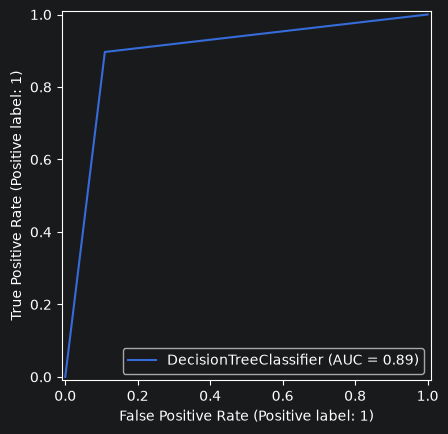

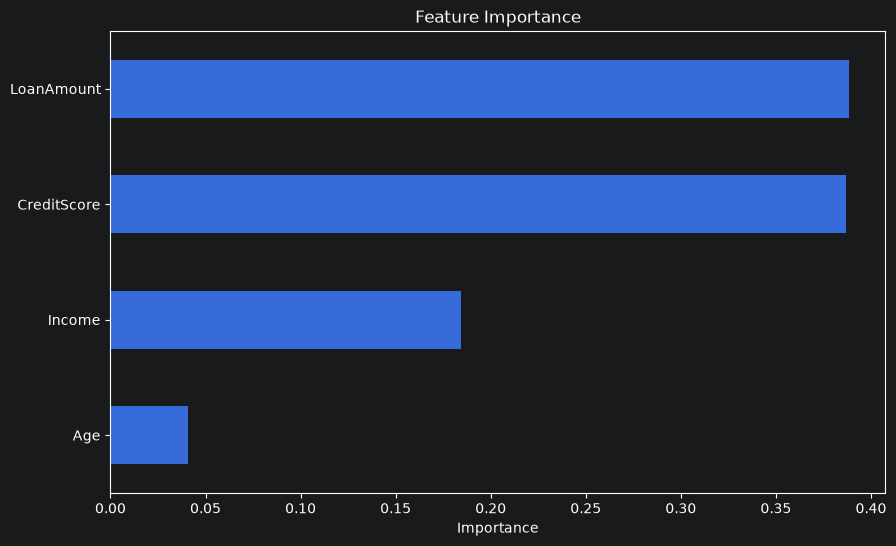

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, RocCurveDisplay

from imblearn.over_sampling import SMOTE

# -----------------------------
# Load Dataset
# -----------------------------
# Replace with your dataset path
df = pd.read_csv("credit_data.csv")

print(df.head())

# -----------------------------
# Handle Missing Values
# -----------------------------
df.fillna(df.mode().iloc[0], inplace=True)

# -----------------------------
# Encode Categorical Columns
# -----------------------------
encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == object:
        df[column] = encoder.fit_transform(df[column])

# -----------------------------
# Features and Target
# -----------------------------
X = df.drop("Default", axis=1)
y = df["Default"]
# -----------------------------
# Train Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# Apply SMOTE
# -----------------------------
#smote = SMOTE(random_state=42)
smote = SMOTE(random_state=42,k_neighbors=2)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE")
print(y_train.value_counts())

# -----------------------------
# Logistic Regression
# -----------------------------
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("\n===== Logistic Regression =====")
print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

print("ROC AUC:",
      roc_auc_score(y_test,
      lr.predict_proba(X_test)[:,1]))

# -----------------------------
# Decision Tree
# -----------------------------
tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

print("\n===== Decision Tree =====")

print("Accuracy:",
      accuracy_score(y_test, tree_pred))

print(classification_report(y_test, tree_pred))

print("ROC AUC:",
      roc_auc_score(y_test,
      tree.predict_proba(X_test)[:,1]))

# -----------------------------
# Confusion Matrix
# -----------------------------
print("\nConfusion Matrix")

print(confusion_matrix(y_test, tree_pred))

# -----------------------------
# ROC Curve
# -----------------------------
RocCurveDisplay.from_estimator(tree, X_test, y_test)

plt.show()

# -----------------------------
# Feature Importance
# -----------------------------
importance = tree.feature_importances_

feature_importance = pd.Series(
    importance,
    index=X.columns
)

feature_importance.sort_values().plot(
    kind="barh",
    figsize=(10,6),
    title="Feature Importance"
)

plt.xlabel("Importance")

plt.show()